# Round 2: Tree-based Models
**Goal**: Train Random Forest and XGBoost with full metrics (Weighted F1, Recall, Precision, Accuracy) and Confusion Matrices.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

sns.set(style='whitegrid')
reports_dir = '/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round2/reports'
os.makedirs(reports_dir, exist_ok=True)

In [ ]:
train_df = pd.read_excel('/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round2/train.xlsx')
val_df = pd.read_excel('/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round2/val.xlsx')
X_train = train_df['cleaned_poem'].astype(str)
X_val = val_df['cleaned_poem'].astype(str)
y_train_p = train_df['primary_id']
y_val_p = val_df['primary_id']
y_train_s = train_df['secondary_id']
y_val_s = val_df['secondary_id']
with open('/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round2/label_maps.json', 'r') as f:
    maps = json.load(f)
p_map = {v: k for k, v in maps['primary_map'].items()}
s_map = {v: k for k, v in maps['secondary_map'].items()}

In [ ]:
def evaluate_and_plot(y_val, y_pred, label_map, prefix):
    acc = accuracy_score(y_val, y_pred)
    f1_w = f1_score(y_val, y_pred, average='weighted')
    prec_w = precision_score(y_val, y_pred, average='weighted', zero_division=0)
    rec_w = recall_score(y_val, y_pred, average='weighted', zero_division=0)
    
    print(f"Assessment for {prefix}:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Weighted F1: {f1_w:.4f}")
    print(f"  Weighted Precision: {prec_w:.4f}")
    print(f"  Weighted Recall: {rec_w:.4f}")
    
    metrics = {'accuracy': acc, 'weighted_f1': f1_w, 'weighted_precision': prec_w, 'weighted_recall': rec_w}
    with open(f'{reports_dir}/{prefix}_metrics.json', 'w') as f:
        json.dump(metrics, f, indent=4)
        
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, cmap='Greens', fmt='d')
    plt.title(f'{prefix} Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(f'{reports_dir}/{prefix}_confusion_matrix.png')
    plt.show()
    
    res = pd.DataFrame({'True': y_val, 'Pred': y_pred})
    if label_map:
        res['True_Label'] = res['True'].map(label_map)
        res['Pred_Label'] = res['Pred'].map(label_map)
    res[res['True'] != res['Pred']].to_csv(f'{reports_dir}/{prefix}_errors.csv', index=False)

In [ ]:
def train_rf(y_train, y_val, label_map, prefix):
    print(f"\nTraining RF for {prefix}...")
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(analyzer='char', ngram_range=(3, 5), max_features=5000)),
        ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=1))
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    evaluate_and_plot(y_val, y_pred, label_map, prefix)

In [ ]:
def train_xgb(y_train, y_val, label_map, prefix):
    print(f"\nTraining XGB for {prefix}...")
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(analyzer='char', ngram_range=(3, 5), min_df=5)),
        ('svd', TruncatedSVD(n_components=100, random_state=42)),
        ('xgb', XGBClassifier(n_estimators=100, random_state=42, n_jobs=1, verbosity=0))
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    evaluate_and_plot(y_val, y_pred, label_map, prefix)


Training RF for rf_primary...
Assessment for rf_primary:
  Accuracy: 0.3673
  Weighted F1: 0.2839
  Weighted Precision: 0.2716
  Weighted Recall: 0.3673


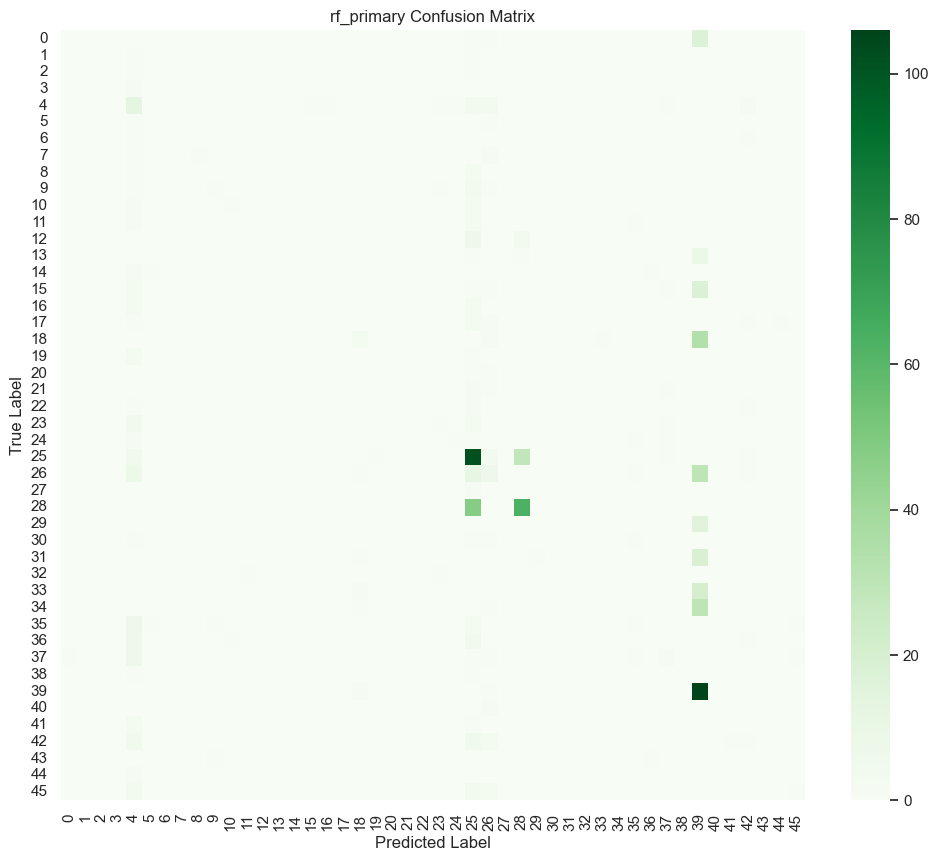


Training RF for rf_secondary...
Assessment for rf_secondary:
  Accuracy: 0.2945
  Weighted F1: 0.2015
  Weighted Precision: 0.2360
  Weighted Recall: 0.2945


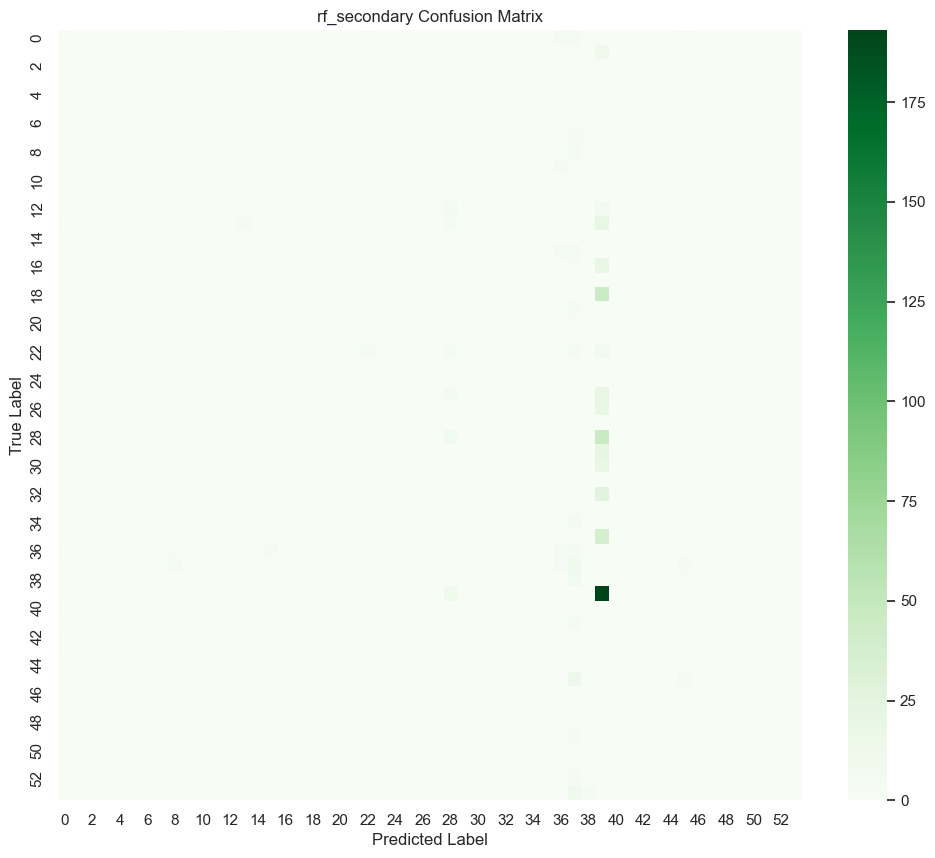


Training XGB for xgb_primary...
Assessment for xgb_primary:
  Accuracy: 0.3879
  Weighted F1: 0.3407
  Weighted Precision: 0.3385
  Weighted Recall: 0.3879


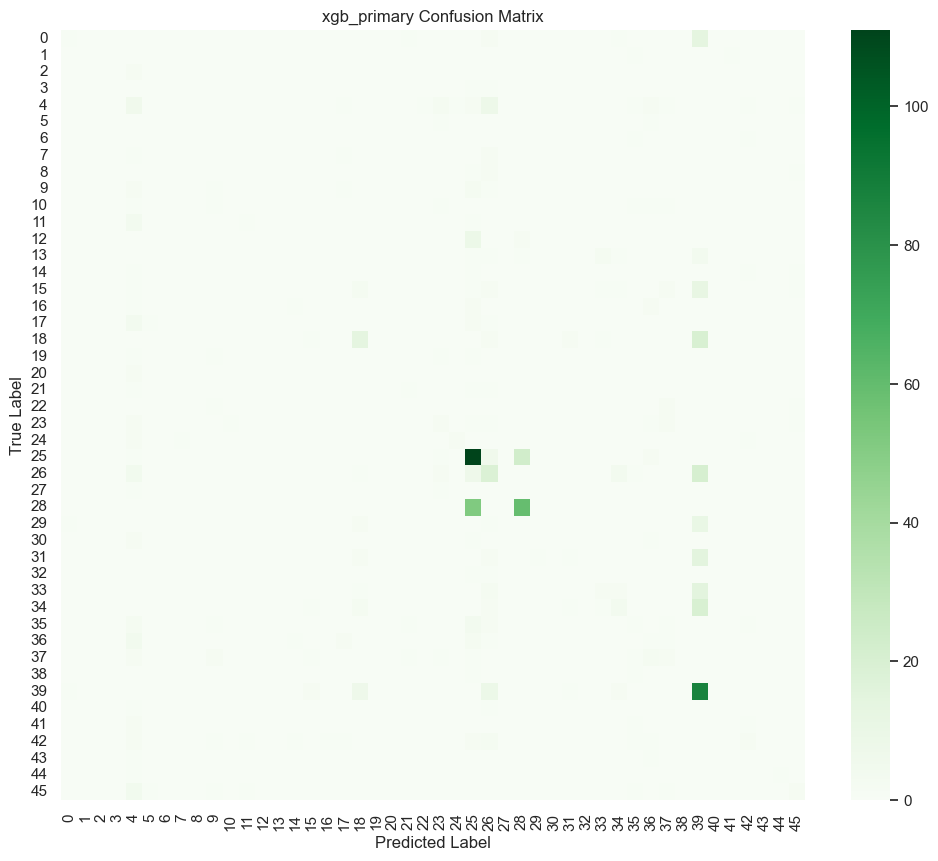


Training XGB for xgb_secondary...
Assessment for xgb_secondary:
  Accuracy: 0.2885
  Weighted F1: 0.2373
  Weighted Precision: 0.2249
  Weighted Recall: 0.2885


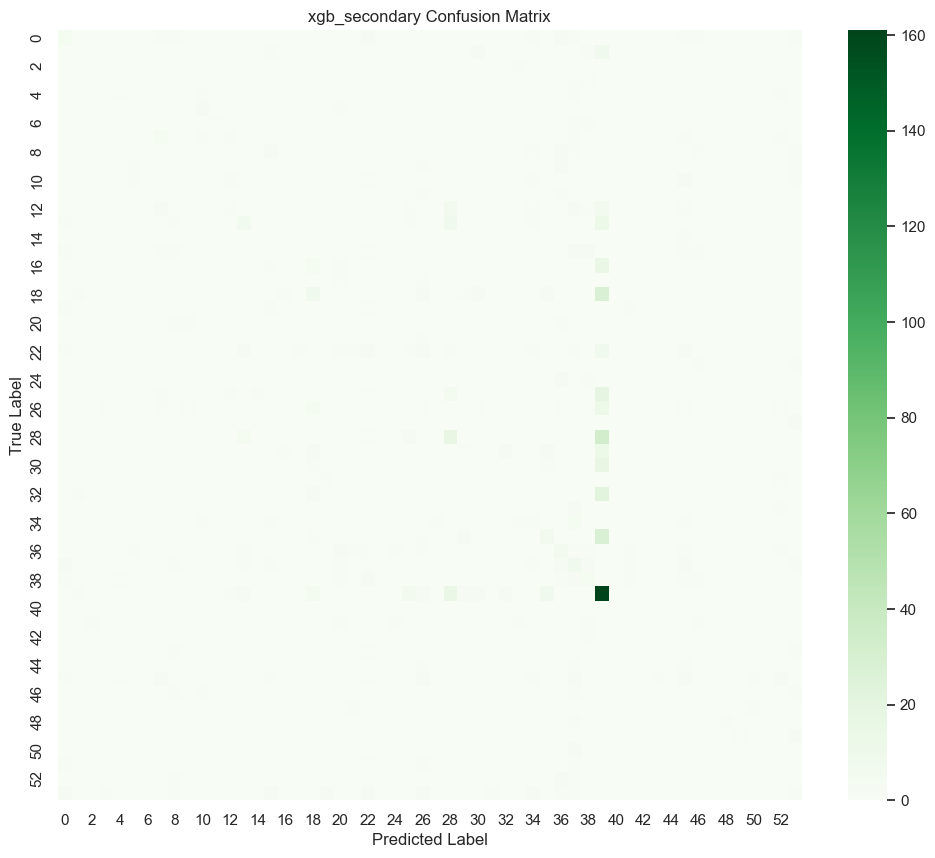

In [ ]:
train_rf(y_train_p, y_val_p, p_map, 'rf_primary')
train_rf(y_train_s, y_val_s, s_map, 'rf_secondary')
train_xgb(y_train_p, y_val_p, p_map, 'xgb_primary')
train_xgb(y_train_s, y_val_s, s_map, 'xgb_secondary')